/tmp/ipykernel_5096/538881035.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
/tmp/ipykernel_5096/538881035.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
/tmp/ipykernel_5096/538881035.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])
/tmp/ipykernel_5096/538881035.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, pl

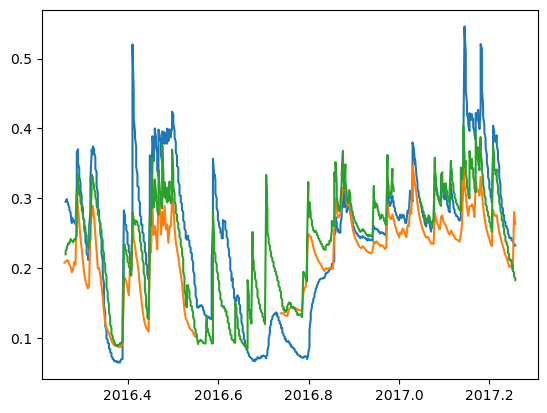

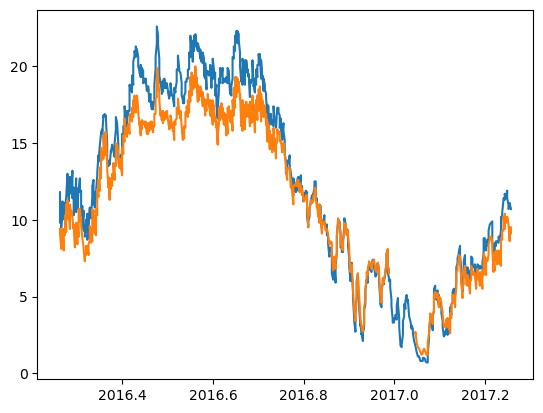

729 730


In [81]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path
import os
import sys
from pathlib import Path
home = Path.home()
subdir = home / "src" / "at-gpflow" / "experiments" / "soil-moisture" / "Wageningen" ## or whatever folder at-gpflow lives in
at_dir = home / "src" / "at-gpflow"


sys.path.append(str(at_dir))
sys.path.append(str(subdir))
BASE = str(subdir)

source = pd.read_csv(BASE+"/data/station_data/RM_SM_15_calibrated.csv")
source2 = pd.read_csv(BASE+"/data/station_data/RM_SM_02_calibrated.csv")
target = pd.read_csv(BASE+"/data/station_data/RM_SM_14_calibrated.csv")
source["Measurement Time"] = pd.to_datetime(source["Measurement Time"])
source2["Measurement Time"] = pd.to_datetime(source2["Measurement Time"])
target["Measurement Time"] = pd.to_datetime(target["Measurement Time"])

source.index = source["Measurement Time"]
source2.index = source2["Measurement Time"]
target.index = target["Measurement Time"]

source = source.resample("12H").last()
source2 = source2.resample("24H").last()
target = target.resample("12H").last()

source['decimal_year'] = source['Measurement Time'].dt.year + (source['Measurement Time'].dt.dayofyear - 1) / 365.25
source2['decimal_year'] = source2['Measurement Time'].dt.year + (source2['Measurement Time'].dt.dayofyear - 1) / 365.25
target['decimal_year'] = target['Measurement Time'].dt.year + (target['Measurement Time'].dt.dayofyear - 1) / 365.25
source.index = source["decimal_year"]
source2.index = source2["decimal_year"]
target.index = target["decimal_year"]


plt.plot(source.index, source["5 cm VWC [m3/m3]"])
plt.plot(source2.index, source2["5 cm VWC [m3/m3]"])
plt.plot(target.index, target["5 cm VWC [m3/m3]"])
plt.show()
plt.plot(source.index, source["5 cm Temp [oC]"])
plt.plot(target.index, target["5 cm Temp [oC]"])
plt.show()

print(len(source), len(target))

2017.2573579739903


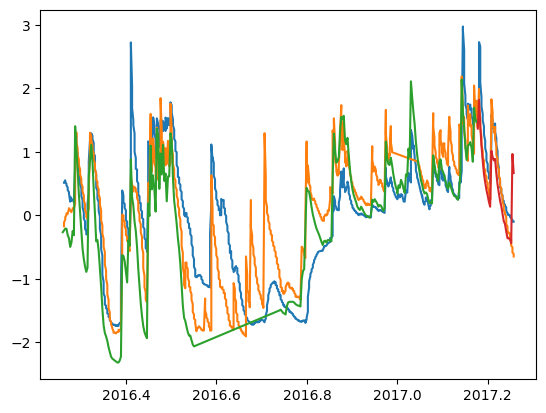

In [82]:
Ax = source.index.to_numpy().reshape(-1, 1)
Bx = target.index.to_numpy().reshape(-1, 1)
Cx = source2.index.to_numpy().reshape(-1, 1)

Ay_nans = source["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1) 
Ay = Ay_nans[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
Ax = Ax[~np.isnan(Ay_nans)].reshape(-1, 1)
Ay = (Ay - Ay.mean()) / np.std(Ay)
By_nans = target["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
By = By_nans[~np.isnan(By_nans)].reshape(-1, 1)
By = (By - By.mean()) / np.std(By)
Bx = Bx[~np.isnan(By_nans)].reshape(-1, 1)


Cy_nans = source2["5 cm VWC [m3/m3]"].to_numpy().reshape(-1, 1)
Cy = Cy_nans[~np.isnan(Cy_nans)].reshape(-1, 1)
Cy = (Cy - Cy.mean()) / np.std(Cy)
Cx = Cx[~np.isnan(Cy_nans)].reshape(-1, 1)

Xtest = Cx[int(len(Cx)*0.9):] 
ytest = Cy[int(len(Cy)*0.9):] 
Cx = Cx[:int(len(Cx)*0.9)] 
Cy = Cy[:int(len(Cy)*0.9)] 

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax))), np.hstack((Bx, np.ones_like(Bx))), np.hstack((Cx, 2*np.ones_like(Cx)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay))), np.hstack((By, np.ones_like(By))), np.hstack((Cy, 2*np.ones_like(Cy)))))
plt.plot(Ax, Ay)
plt.plot(Bx, By)
plt.plot(Cx, Cy)
plt.plot(Xtest, ytest)
print(np.max(X))

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value      │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0        │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0        │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤

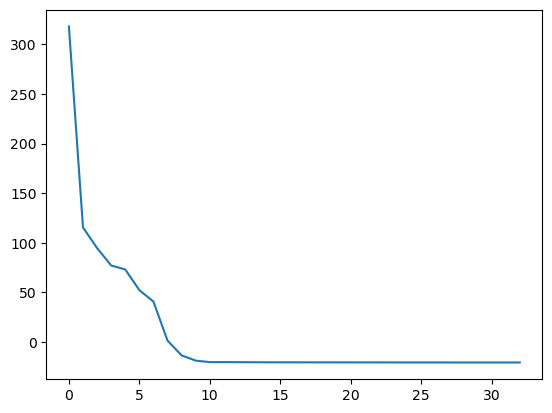

╒════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════╕
│ name                                               │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                              │
╞════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════╡
│ ConditionalMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.624377762314254                  │
├────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────┤
│ ConditionalMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.019238854099569488               

In [83]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = 3 # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

model1 = ConditionalMOGP((X, y), kernel=kern, conditioning_index=2, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-6, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)

gpf.utilities.print_summary(model1)
optimize(model1)
gpf.utilities.print_summary(model1)


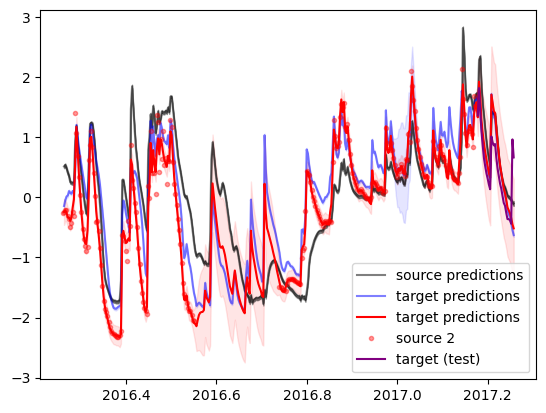

tf.Tensor(
[[ 1.3341341 ]
 [ 1.92581086]
 [ 1.67063963]
 [ 1.28039555]
 [ 1.06865818]
 [ 0.90316744]
 [ 0.75519154]
 [ 0.63191014]
 [ 0.51573261]
 [ 0.40297357]
 [ 0.3294919 ]
 [ 1.71097324]
 [ 1.57385271]
 [ 1.43698233]
 [ 1.40446058]
 [ 1.13134732]
 [ 0.90913099]
 [ 0.71573194]
 [ 0.54054022]
 [ 0.40757125]
 [ 0.27419942]
 [ 0.14754343]
 [ 0.07036689]
 [-0.03778934]
 [-0.16607029]
 [-0.21295165]
 [-0.26060957]
 [-0.34270562]
 [-0.44711571]
 [-0.51530563]], shape=(30, 1), dtype=float64) [[ 1.36482561]
 [ 1.82014668]
 [ 1.42269534]
 [ 1.09821756]
 [ 0.85842305]
 [ 0.65070296]
 [ 0.51968997]
 [ 0.4008958 ]
 [ 0.31163047]
 [ 0.21201308]
 [ 0.1358151 ]
 [ 1.01506165]
 [ 0.91595337]
 [ 0.8655507 ]
 [ 0.88727306]
 [ 0.65833973]
 [ 0.48048789]
 [ 0.3523599 ]
 [ 0.22881397]
 [ 0.1443004 ]
 [ 0.02346976]
 [-0.09209999]
 [-0.13724177]
 [-0.25722388]
 [-0.36125363]
 [-0.36125363]
 [-0.38060011]
 [-0.43863955]
 [ 0.96567721]
 [ 0.6659765 ]]


0.211431944694653

In [84]:
from sklearn.metrics import mean_squared_error
Xtst = Xtest.reshape(-1, 1)
Xall = Ax
Xplot = np.hstack((Xall, np.zeros_like(Xall)))
Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
Xplot3 = np.hstack((Xall, 2*np.ones_like(Xall)))
Xtest_stack = np.hstack((Xtst, 2*np.ones_like(Xtst)))
fmean, fvar = model1.predict_f(Xplot)
fmean2, fvar2 = model1.predict_f(Xplot2)
fmean3, fvar3 = model1.predict_f(Xplot3)
fmean_tst, fvar_tst = model1.predict_f(Xtest_stack)
plt.plot(Xall, fmean, color="k", alpha=0.5, label="source predictions")
plt.plot(Xall, fmean2, color="b", alpha=0.5, label="target predictions")
plt.plot(Xall, fmean3, color="r", label="target predictions")
# plt.plot(Ax, Ay, "k.", alpha=0.4, label="source")
# plt.plot(Bx, By, "b.", alpha=0.4, label="target")
plt.plot(Cx, Cy, "r.", alpha=0.4, label="source 2")
plt.plot(Xtest, ytest, "purple", alpha=1, label="target (test)")
plt.fill_between(
    Xall[:, 0],
    (fmean3 - 2 * np.sqrt(fvar3))[:, 0],
    (fmean3 + 2 * np.sqrt(fvar3))[:, 0],
    color="r",
    alpha=0.1,
)
plt.fill_between(
    Xall[:, 0],
    (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
    (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
    color="b",
    alpha=0.1,
)
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="k",
    alpha=0.4,
)
plt.legend()
#plt.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*0, marker="x", c=ivs[:,1], zorder=100, s=100, alpha=0.6)
plt.show()
print(fmean_tst, ytest)
ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

noise with 3: 0.007 - 
noise with 2: 0.095 - 0.033

(150, 2) (1685, 2) (1685, 2)
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value      │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0        │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0        │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────

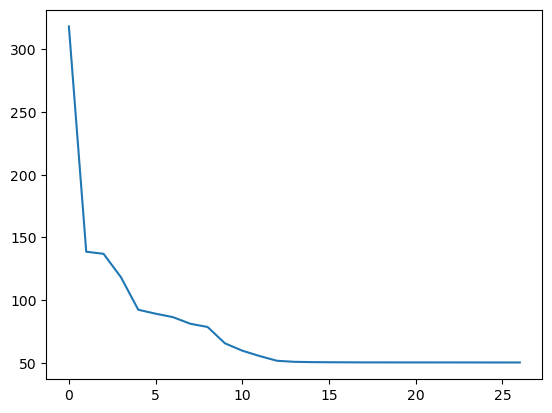

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                              │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.6228087197309249                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.05109997151411979                │
├─────────────────────

In [85]:
from atmodel import SparseCMOGP, ConditionalMOGP
from atlikelihood import TransferLikelihood
import gpflow as gpf
from robust_svgp import LMCInducingVariable, LMCInducingPointsBase

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()

output_dim = 3 # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)
nIVS = 50 * output_dim
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = [j * np.ones((int(nIVS/output_dim), 1)) for j in range(output_dim)]
iv_ind = np.concatenate(iv_ind)  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
print(ivs.shape, X.shape, y.shape)
kern = k * coreg
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
model2 = SparseCMOGP((X, y), conditioning_index=2, exact_target=False, kernel=kern, jitter=1e-5, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.likelihood.source.variance, False)
#print(model2.conditional_likelihood(decompose_likelihood=True))

gpf.utilities.print_summary(model2)
optimize(model2)
gpf.utilities.print_summary(model2)
print(model2.inducing_variable.Z)

In [86]:
W = model2.kernel.kernels[1].W.numpy()
print(W@W.T)

[[ 6.11650328 10.4222507  11.60968156]
 [10.4222507  17.75905359 19.78238319]
 [11.60968156 19.78238319 22.03623537]]


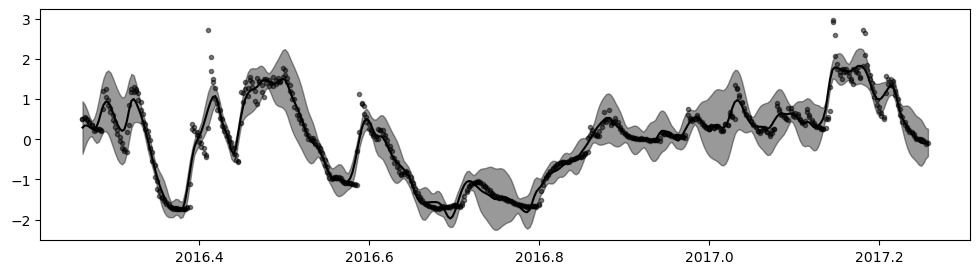

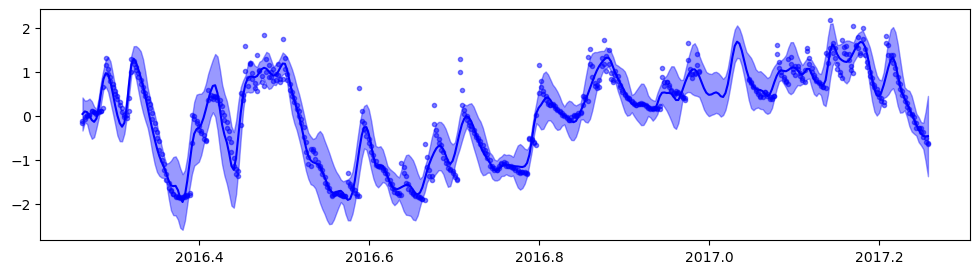

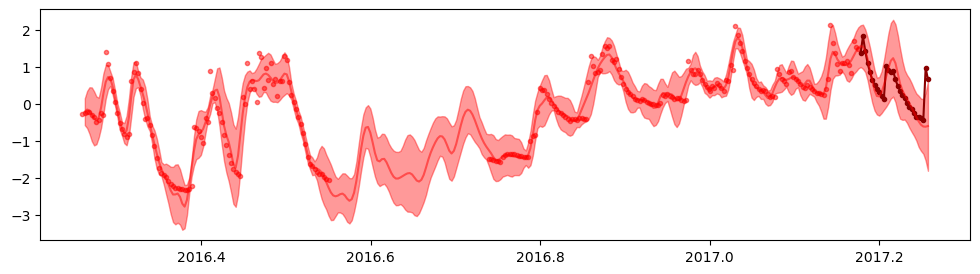

0.17371974431618073

In [90]:
from sklearn.metrics import mean_squared_error
Xtst = Xtest.reshape(-1, 1)
Xall = Ax
Xplot = np.hstack((Xall, np.zeros_like(Xall)))
Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
Xplot3 = np.hstack((Xall, 2*np.ones_like(Xall)))
Xtest_stack = np.hstack((Xtst, 2*np.ones_like(Xtst)))
fmean, fvar = model2.predict_f(Xplot)
fmean2, fvar2 = model2.predict_f(Xplot2)
fmean3, fvar3 = model2.predict_f(Xplot3)
fmean_tst, fvar_tst = model2.predict_f(Xtest_stack)
plt.figure(figsize=(12, 3))
plt.plot(Xall, fmean, color="k", label="source predictions")
plt.plot(Ax, Ay, "k.", alpha=0.5, label="source")
plt.fill_between(
    Xall[:, 0],
    (fmean - 2 * np.sqrt(fvar))[:, 0],
    (fmean + 2 * np.sqrt(fvar))[:, 0],
    color="k",
    alpha=0.4,
)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(Bx, By, "b.", alpha=0.5, label="target")
plt.plot(Xall, fmean2, color="b", label="target predictions")
plt.fill_between(
    Xall[:, 0],
    (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
    (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
    color="b",
    alpha=0.4,
)
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(Cx, Cy, "r.", alpha=0.5, label="target")
plt.plot(Xtest, ytest, color="darkred", marker=".")
plt.plot(Xall, fmean3, color="r", alpha=0.5, linestyle="-", label="target predictions")
plt.fill_between(
    Xall[:, 0],
    (fmean3 - 2 * np.sqrt(fvar3))[:, 0],
    (fmean3 + 2 * np.sqrt(fvar3))[:, 0],
    color="r",
    alpha=0.4,
)
plt.show()

ours_mse = mean_squared_error(ytest, fmean_tst)
ours_mse

In [ ]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
from robust_svgp import LMCInducingPointsBase
output_dim = 3 # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Matern32(active_dims=[0])

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = TransferLikelihood(
    source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()
)
nIVS = 50*output_dim
print(X)
ivs = np.linspace(np.min(X[:,0]), np.max(X[:,0]), nIVS).reshape(-1, 1)
iv_ind = np.concatenate((2*np.ones((int(nIVS/3),1 )), np.ones((int(nIVS/3),1 )), np.zeros((int(nIVS/3), 1))))  # I guess the IPs for the target don't matter here, but this makes the comparison fair.
shuffle = np.random.permutation(np.arange(len(ivs)))
ivs = ivs[shuffle]
ivs = np.hstack((ivs, iv_ind))
# now build the GP model as normal
model3 = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))

# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    model3.training_loss_closure((X, y)),
    model3.trainable_variables,
    method="L-BFGS-B",
)

gpf.utilities.print_summary(model3)

[[2.01626283e+03 0.00000000e+00]
 [2.01626283e+03 0.00000000e+00]
 [2.01626557e+03 0.00000000e+00]
 ...
 [2.01716975e+03 2.00000000e+00]
 [2.01717248e+03 2.00000000e+00]
 [2.01717522e+03 2.00000000e+00]]


2026-09-04 13:54:14.127267: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: partitions[1417] = 2 is not in [0, 2)
	 [[{{node DynamicPartition_4}}]]
2026-09-04 13:54:14.127510: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: partitions[1417] = 2 is not in [0, 2)
	 [[{{node DynamicPartition_4}}]]
2026-09-04 13:54:14.206708: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: partitions[1417] = 2 is not in [0, 2)
	 [[{{node DynamicPartition_4}}]]
2026-09-04 13:54:14.206937: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (

InvalidArgumentError: Graph execution error:

Detected at node 'DynamicPartition_3' defined at (most recent call last):
    File "<frozen runpy>", line 198, in _run_module_as_main
    File "<frozen runpy>", line 88, in _run_code
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
      self.asyncio_loop.run_forever()
    File "/home/janneke/miniforge3/envs/dev/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
      self._run_once()
    File "/home/janneke/minifo

TensorShape([1348, 729])
TensorShape([1348, 729])
TensorShape([1348, 69])
MSE is 0.09000094286679697
MSE is 0.0952425711277527
MSE is 0.23051151179216423


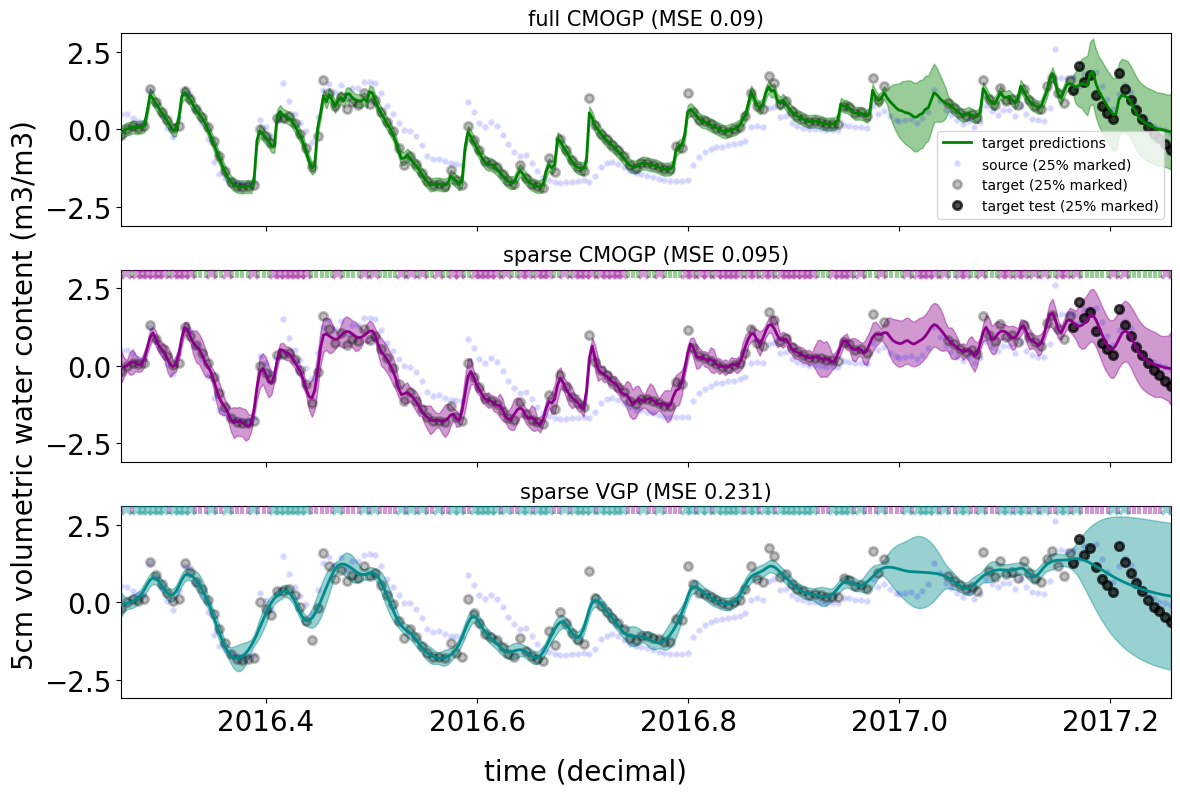

In [ ]:
from sklearn.metrics import mean_squared_error

from matplotlib.legend_handler import HandlerTuple
colors = ["green", "darkmagenta", "darkcyan"]
fig, ax = plt.subplots(3, 1, figsize=(12, 8))
for i ,(name, m) in enumerate(zip(["full CMOGP", "sparse CMOGP", "sparse VGP"], [model1, model2, model3])):
    Xtst = Xtest.reshape(-1, 1)
    Xall = Ax
    Xplot = np.hstack((Xall, np.zeros_like(Xall)))
    Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
    Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
    fmean, fvar = m.predict_f(Xplot)
    fmean2, fvar2 = m.predict_f(Xplot2)
    fmean_tst, fvar_tst = m.predict_f(Xtest_stack)
    #ax[i].plot(Xall, fmean, color=colors[i], lw =2, label="source predictions" if i ==0 else "__nolegend__")
    ax[i].plot(Xall, fmean2, color=colors[i], lw=2, zorder=100, label="target predictions")
    ax[i].plot(Ax, Ay, "b.", markevery=4, ms=6, mew=2, alpha=0.1, label="source (25% marked)")
    ax[i].plot(Bx, By, "k.", markevery=4, ms=12, mew=2, alpha=0.25, label="target (25% marked)")
    ax[i].plot(Xtest, ytest, "k.", markevery=4, ms=12, mew=2, alpha=0.7, label="target test (25% marked)")
    fig.supxlabel("time (decimal)", fontsize=20)
    fig.supylabel("5cm volumetric water content (m3/m3)", fontsize=20)
    ours_mse = mean_squared_error(ytest, fmean_tst)
    ax[i].set_title(name + f" (MSE {np.round(ours_mse, 3)})", fontsize=15)
    if i < 2:
        ax[i].set_xticklabels([])
    ax[i].tick_params(axis='both', labelsize=20)
    ax[i].fill_between(
        Xall[:, 0],
        (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
        (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
        color=colors[i],
        alpha=0.4,
    )
    # # ax[i].fill_between(
    # #     Xall[:, 0],
    # #     (fmean - 2 * np.sqrt(fvar))[:, 0],
    # #     (fmean + 2 * np.sqrt(fvar))[:, 0],
    # #     color="k",
    # #     alpha=0.4,
    # )
    if "sparse" in name:
        iv_index = m.inducing_variable.Z[:,1]
        handle1 = ax[i].scatter(m.inducing_variable.Z[:,0][iv_index == 0], np.ones_like(ivs[:,0][iv_index == 0])*3, marker="|",c=colors[i-1], zorder=10, s=50, linewidth=3, alpha=0.4, label= "IVs (source/target)")
        handle2 = ax[i].scatter(m.inducing_variable.Z[:,0][iv_index == 1], np.ones_like(ivs[:,0][iv_index == 1])*3, marker="x", c=colors[i], zorder=10, s=50, linewidth=3, alpha=0.4)

    else:
        ax[i].legend(loc="lower right")
    ax[i].set_xlim(np.min(X[:,0]), np.max(X[:,0]))
    ax[i].set_ylim(-3.1, 3.1)
    plt.tight_layout()
    print("MSE is", ours_mse)

TensorShape([3214, 1372])
TensorShape([3214, 1372])
TensorShape([3214, 73])
MSE is 0.13453459028656944
sparse CMOGP
MSE is 1.9240458114953145
sparse VGP
MSE is 0.46095414887671443


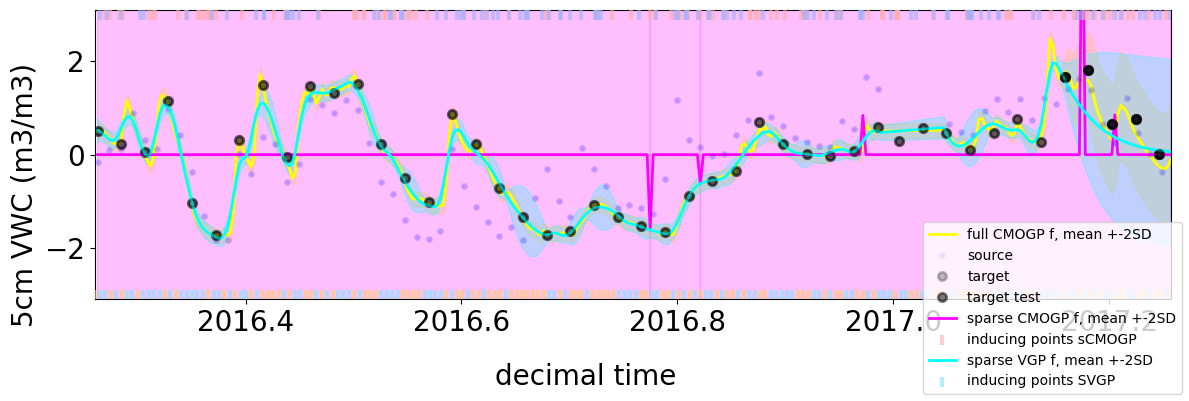

In [ ]:
from sklearn.metrics import mean_squared_error

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

colors = ["yellow", "magenta", "cyan"]
for i ,(name, m) in enumerate(zip(["full CMOGP", "sparse CMOGP", "sparse VGP"], [model1, model2, model3])):
    Xtst = Xtest.reshape(-1, 1)
    Xall = Ax
    Xplot = np.hstack((Xall, np.zeros_like(Xall)))
    Xplot2 = np.hstack((Xall, np.ones_like(Xall)))
    Xtest_stack = np.hstack((Xtst, np.ones_like(Xtst)))
    fmean, fvar = m.predict_f(Xplot)
    fmean2, fvar2 = m.predict_f(Xplot2)
    fmean_tst, fvar_tst = m.predict_f(Xtest_stack)
    #ax[0].plot(Xall, fmean, color="k", lw =2, label="source predictions" if i ==0 else "__nolegend__")
    ax.plot(Xall, fmean2, color=colors[i], lw=2, label=f"{name} f, mean +-2SD")
    ax.plot(Ax, Ay, "b.", markevery=16, ms=6, mew=2, alpha=0.05, label="source" if i == 0 else "__nolegend__")
    ax.plot(Bx, By, "k.", markevery=16, ms=12, mew=2, alpha=0.25, label="target" if i == 0 else "__nolegend__")
    ax.plot(Xtest, ytest, "k.", markevery=16, ms=12, mew=2, alpha=0.5, label="target test" if i == 0 else "__nolegend__")
    fig.supxlabel("decimal time", fontsize=20)
    fig.supylabel("5cm VWC (m3/m3)", fontsize=20)
    ours_mse = mean_squared_error(ytest, fmean_tst)
    #ax.set_title(name + f"(MSE {np.round(ours_mse, 3)})", fontsize=15)
    if i < -1:
        ax.set_xticklabels([])
    ax.tick_params(axis='both', labelsize=20)
    ax.fill_between(
        Xall[:, 0],
        (fmean2 - 2 * np.sqrt(fvar2))[:, 0],
        (fmean2 + 2 * np.sqrt(fvar2))[:, 0],
        color=colors[i],
        alpha=0.25,
    )
    if "sparse" in name:
        print(name)
        ax.scatter(m.inducing_variable.Z[:,0], np.ones_like(ivs[:,0])*3 if i == 1 else np.ones_like(ivs[:,0]) * -3, marker="|", c=m.inducing_variable.Z[:,1], cmap="berlin" if i == 1 else "managua",  zorder=100, s=50, linewidth=3, alpha=0.6, label= "inducing points sCMOGP" if i == 1 else "inducing points SVGP")
    ax.set_xlim(np.min(X[:,0]), np.max(X[:,0]))
    ax.set_ylim(-3.1, 3.1)
    print("MSE is", ours_mse)

fig.legend(loc="lower right", ncol=1)
plt.tight_layout()